In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

import time

In [4]:
df = pd.read_csv('../data/clean/imdb_clean.csv')

In [ ]:

from sklearn.model_selection import train_test_split

def division_train_test(df, text_col='tokenized_review_clean', target_col='sentiment', 
                        test_size=0.2, valid_size=0.1, random_state=42):
    """
    Divise le dataset en 3 parties : train (70%) / valid (10%) / test (20%)
    
    La validation sert à choisir le meilleur max_features.
    Le test sert à l'évaluation finale — touché une seule fois à la fin.
    """
    x = df[text_col]
    y = df[target_col]   
    x_temp, x_test, y_temp, y_test = train_test_split(
        x, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )    # Étape 2 : séparer valid (10%) du reste (70%)
    # valid_size relatif au temp = 0.1 / 0.8 = 0.125
    valid_size_relative = valid_size / (1 - test_size)
    x_train, x_valid, y_train, y_valid = train_test_split(
        x_temp, y_temp,
        test_size=valid_size_relative,
        random_state=random_state,
        stratify=y_temp
    )
    print(f" Division effectuée:")
    print(f"   Train: {len(x_train)} échantillons")
    print(f"   Valid: {len(x_valid)} échantillons")
    print(f"   Test: {len(x_test)} échantillons")
    print(f"   Proportion positif en train: {y_train.mean():.2f}")
    print(f"   Proportion positif en valid: {y_valid.mean():.2f}")
    print(f"   Proportion positif en test: {y_test.mean():.2f}")
    return x_train, x_valid, x_test, y_train, y_valid, y_test

x_train, x_valid, x_test, y_train, y_valid, y_test = division_train_test(df)

✅ Division effectuée:
   Train: 34706 échantillons
   Valid: 4959 échantillons
   Test: 9917 échantillons
   Proportion positif en train: 0.50
   Proportion positif en valid: 0.50
   Proportion positif en test: 0.50


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def vectoriser(x_train, x_valid, x_test, ngram_range=(1, 2), max_features=30000, min_df=3):
    """
    Vectorisation TF-IDF avec bigrammes.
    
    Paramètres:
    -----------
    x_train : pd.Series — textes d'entraînement (déjà tokenisés + joints en string)
    x_valid : pd.Series — textes de validation
    x_test  : pd.Series — textes de test
    ngram_range  : tuple — (1,2) = unigrammes + bigrammes
    max_features : int   — taille max du vocabulaire
    min_df       : int   — ignorer les mots présents dans moins de N documents
    
    Retourne:
    ---------
    x_train_vec, x_valid_vec, x_test_vec, vectorizer
    """
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=min_df,
        sublinear_tf=True,   
        strip_accents='unicode',  
        analyzer='word',          
    )
    
    x_train_vec = vectorizer.fit_transform(x_train)  
    x_valid_vec = vectorizer.transform(x_valid)
    x_test_vec  = vectorizer.transform(x_test)        
    
    print(f" Vectorisation effectuée:")
    print(f"   Taille du vocabulaire : {len(vectorizer.vocabulary_)}")
    print(f"   Shape train : {x_train_vec.shape}")
    print(f"   Shape valid : {x_valid_vec.shape}")
    print(f"   Shape test  : {x_test_vec.shape}")
    print(f"   Densité matrice train : {x_train_vec.nnz / (x_train_vec.shape[0] * x_train_vec.shape[1]):.4f}")
    
    return x_train_vec, x_valid_vec, x_test_vec, vectorizer



🔍 Test des max_features sur la validation set...

  max_features= 30000 | Accuracy=89.21% | F1=89.21%
  max_features= 32000 | Accuracy=89.09% | F1=89.09%
  max_features= 34000 | Accuracy=89.31% | F1=89.31%
  max_features= 36000 | Accuracy=88.99% | F1=88.99%
  max_features= 38000 | Accuracy=89.21% | F1=89.21%
  max_features= 40000 | Accuracy=89.31% | F1=89.31%

✅ Meilleur max_features : 34000 (F1=89.31%)


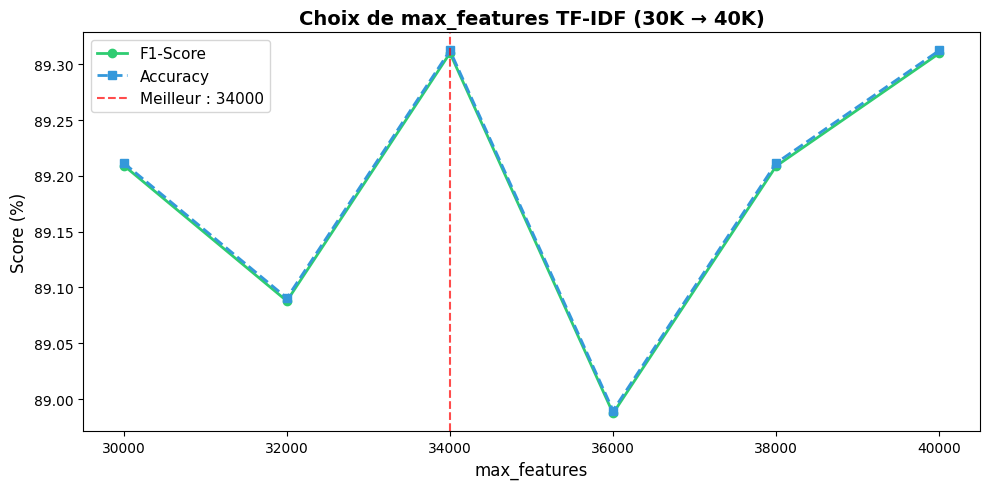

In [ ]:
# ============================================================
# TEST : Choix du meilleur max_features (30 000 → 40 000)
# À exécuter AVANT la vectorisation finale
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

max_features_values = [30000, 32000, 34000, 36000, 38000, 40000]
results_maxfeat = []

print(" Test des max_features sur la validation set...\n")
for max_feat in max_features_values:
    tfidf_test = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=max_feat,
        min_df=3,
        sublinear_tf=True,
        strip_accents='unicode',
        analyzer='word'
    )
    Xtr = tfidf_test.fit_transform(x_train)
    Xva = tfidf_test.transform(x_valid)

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(Xtr, y_train)
    y_pred = lr.predict(Xva)

    f1  = f1_score(y_valid, y_pred, average='weighted')
    acc = lr.score(Xva, y_valid)

    results_maxfeat.append({'max_features': max_feat, 'F1-Score': f1, 'Accuracy': acc})
    print(f"  max_features={max_feat:>6} | Accuracy={acc*100:.2f}% | F1={f1*100:.2f}%")

# ---- Meilleur choix ----
df_maxfeat = pd.DataFrame(results_maxfeat)
best_row   = df_maxfeat.loc[df_maxfeat['F1-Score'].idxmax()]
best_max   = int(best_row['max_features'])
print(f"\n Meilleur max_features : {best_max} (F1={best_row['F1-Score']*100:.2f}%)")

# ---- Visualisation ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_maxfeat['max_features'], df_maxfeat['F1-Score']*100,
        'o-', color='#2ecc71', lw=2, label='F1-Score')
ax.plot(df_maxfeat['max_features'], df_maxfeat['Accuracy']*100,
        's--', color='#3498db', lw=2, label='Accuracy')
ax.axvline(x=best_max, color='red', linestyle='--', alpha=0.7,
           label=f"Meilleur : {best_max}")
ax.set_xlabel('max_features', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Choix de max_features TF-IDF (30K → 40K)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(max_features_values)
plt.tight_layout()
plt.show()

In [8]:
x_train_vec, x_valid_vec, x_test_vec, vectorizer = vectoriser(x_train, x_valid, x_test, max_features=best_max)

✅ Vectorisation effectuée:
   Taille du vocabulaire : 34000
   Shape train : (34706, 34000)
   Shape valid : (4959, 34000)
   Shape test  : (9917, 34000)
   Densité matrice train : 0.0029


Entrainement du modéle de regression logistique

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier


def get_all_models():
    models = {
        'Logistic Regression': LogisticRegression(
            C=1.0, solver='saga', max_iter=1000,
            random_state=42, n_jobs=-1
        ),
        'SVM (LinearSVC)': CalibratedClassifierCV(
            LinearSVC(C=1.0, max_iter=2000, random_state=42)
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=20, min_samples_split=5,
            random_state=42, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            use_label_encoder=False, eval_metric='logloss',
            random_state=42, n_jobs=-1, tree_method='hist'
        ),
        'MLP (Réseau de neurones)': MLPClassifier(
            hidden_layer_sizes=(256, 128, 64),
            activation='relu', solver='adam',
            max_iter=50, early_stopping=True,
            validation_fraction=0.1,
            random_state=42
        ),
    }
    return models
print("Modèles définis:")
for name in get_all_models():
    print(f"  ✓ {name}")

Modèles définis:
  ✓ Logistic Regression
  ✓ SVM (LinearSVC)
  ✓ Random Forest
  ✓ XGBoost
  ✓ MLP (Réseau de neurones)


In [ ]:
def entrainer_tous_modeles(x_train_vec, y_train):
    models = get_all_models()
    trained_models = {}
    print("=" * 55)
    print("ENTRAÎNEMENT DES MODÈLES ML")
    print("=" * 55)
    for nom, model in models.items():
        print(f"\n {nom}...")
        start = time.time()
        model.fit(x_train_vec, y_train)
        elapsed = time.time() - start
        trained_models[nom] = model
        print(f"    Terminé en {elapsed:.1f}s")
    return trained_models
trained_models = entrainer_tous_modeles(x_train_vec, y_train)

ENTRAÎNEMENT DES MODÈLES ML

⏳ Logistic Regression...
   ✅ Terminé en 0.6s

⏳ SVM (LinearSVC)...
   ✅ Terminé en 1.1s

⏳ Random Forest...
   ✅ Terminé en 1.3s

⏳ XGBoost...


c:\Users\wided\.conda\envs\avis_clients\lib\site-packages\xgboost\training.py:200: UserWarning: [23:27:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   ✅ Terminé en 176.9s

⏳ MLP (Réseau de neurones)...
   ✅ Terminé en 517.0s


Evaluation du modele 

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve


def evaluer_modele(model, X_vec, y, nom_modele):
    """Évalue un modèle et retourne ses métriques (sans affichage)."""
    y_pred  = model.predict(X_vec)
    y_proba = model.predict_proba(X_vec)[:, 1]
    
    accuracy  = accuracy_score(y, y_pred)
    f1        = f1_score(y, y_pred, average='weighted')
    auc_score = roc_auc_score(y, y_proba)
    fpr, tpr, _ = roc_curve(y, y_proba)

    print(f"\n{'='*55}")
    print(f"  {nom_modele}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy*100:.2f}%")
    print(f"  F1-Score  : {f1*100:.2f}%")
    print(f"  ROC-AUC   : {auc_score:.4f}")
    print(classification_report(y, y_pred, target_names=['Négatif', 'Positif']))

    return {
        'nom'      : nom_modele,
        'accuracy' : accuracy,
        'f1_score' : f1,
        'auc'      : auc_score,
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
        'fpr'      : fpr,
        'tpr'      : tpr,
    }
resultats_ml = {}
for nom, model in trained_models.items():
    resultats_ml[nom] = evaluer_modele(model, x_test_vec, y_test, nom)


  Logistic Regression
  Accuracy  : 89.64%
  F1-Score  : 89.64%
  ROC-AUC   : 0.9623
              precision    recall  f1-score   support

     Négatif       0.91      0.88      0.89      4940
     Positif       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917


  SVM (LinearSVC)
  Accuracy  : 90.19%
  F1-Score  : 90.19%
  ROC-AUC   : 0.9639
              precision    recall  f1-score   support

     Négatif       0.91      0.90      0.90      4940
     Positif       0.90      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917


  Random Forest
  Accuracy  : 84.74%
  F1-Score  : 84.72%
  ROC-AUC   : 0.9263
              precision    recall  f1-score   support

     Négatif       0.88      0.81      0.84

CROSS-VALIDATION 5-FOLD (sur le train set)

⏳ CV pour Logistic Regression...
   Accuracy CV : 0.8947 ± 0.0030
   F1      CV : 0.8946 ± 0.0030
   ROC-AUC CV : 0.9600 ± 0.0023

⏳ CV pour SVM (LinearSVC)...
   Accuracy CV : 0.8979 ± 0.0040
   F1      CV : 0.8979 ± 0.0040
   ROC-AUC CV : 0.9617 ± 0.0021

⏳ CV pour Random Forest...
   Accuracy CV : 0.8466 ± 0.0014
   F1      CV : 0.8464 ± 0.0014
   ROC-AUC CV : 0.9267 ± 0.0023


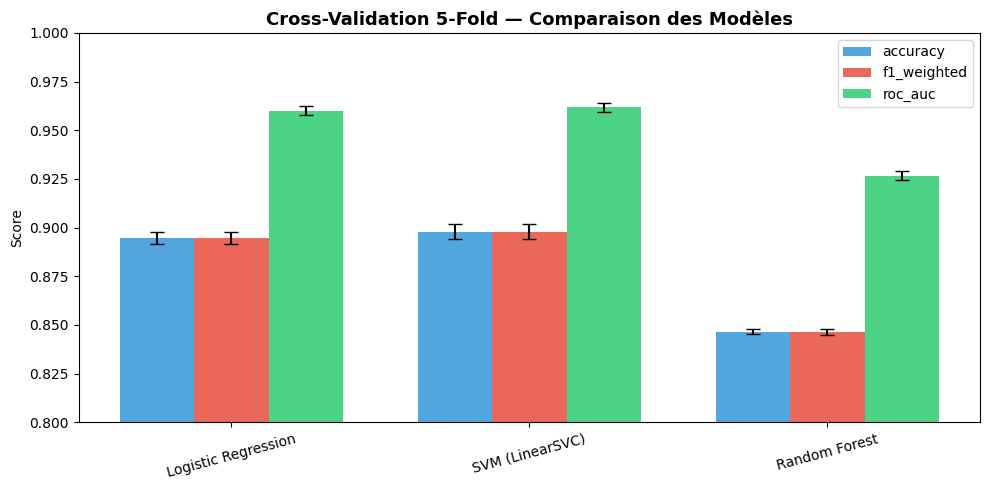

In [14]:
# ============================================================
# Cross-Validation 5-Fold sur le train set
# (on utilise le vectorizer déjà fitté → X_train_vec)
# ============================================================

import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 55)
print("CROSS-VALIDATION 5-FOLD (sur le train set)")
print("=" * 55)

cv_resultats = {}
# Pour la CV on utilise les modèles rapides (LR, SVM)
modeles_cv = {
    'Logistic Regression': trained_models['Logistic Regression'],
    'SVM (LinearSVC)'    : trained_models['SVM (LinearSVC)'],
    'Random Forest'      : trained_models['Random Forest'],
}

for nom, model in modeles_cv.items():
    print(f"\n⏳ CV pour {nom}...")
    scores = cross_validate(
        model, x_train_vec, y_train,
        cv=cv,
        scoring=['accuracy', 'f1_weighted', 'roc_auc'],
        n_jobs=-1
    )
    cv_resultats[nom] = scores
    print(f"   Accuracy CV : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"   F1      CV : {scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}")
    print(f"   ROC-AUC CV : {scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}")

# Visualisation des scores CV
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(modeles_cv))
width = 0.25
COLORS    = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#1abc9c', '#9b59b6']
for i, metric in enumerate(['test_accuracy', 'test_f1_weighted', 'test_roc_auc']):
    means = [cv_resultats[nom][metric].mean() for nom in modeles_cv]
    stds  = [cv_resultats[nom][metric].std()  for nom in modeles_cv]
    ax.bar(x + i*width, means, width, yerr=stds, label=metric.replace('test_', ''), color=COLORS[i], alpha=0.85, capsize=5)

ax.set_xticks(x + width)
ax.set_xticklabels(list(modeles_cv.keys()), rotation=15)
ax.set_ylabel('Score')
ax.set_ylim([0.8, 1.0])
ax.set_title('Cross-Validation 5-Fold — Comparaison des Modèles', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Comparaison entre les modéles 

In [15]:
# ============================================================
# Tableau comparatif de tous les modèles
# ============================================================
df_resultats = pd.DataFrame([
    {
        'Modèle'   : r['nom'],
        'Accuracy' : f"{r['accuracy']*100:.2f}%",
        'F1-Score' : f"{r['f1_score']*100:.2f}%",
        'ROC-AUC'  : f"{r['auc']:.4f}",
    }
    for r in resultats_ml.values()
])

print("=" * 65)
print("TABLEAU COMPARATIF — TOUS LES MODÈLES")
print("=" * 65)
print(df_resultats.to_string(index=False))

TABLEAU COMPARATIF — TOUS LES MODÈLES
                  Modèle Accuracy F1-Score ROC-AUC
     Logistic Regression   89.64%   89.64%  0.9623
         SVM (LinearSVC)   90.19%   90.19%  0.9639
           Random Forest   84.74%   84.72%  0.9263
                 XGBoost   86.21%   86.20%  0.9409
MLP (Réseau de neurones)   89.66%   89.66%  0.9622


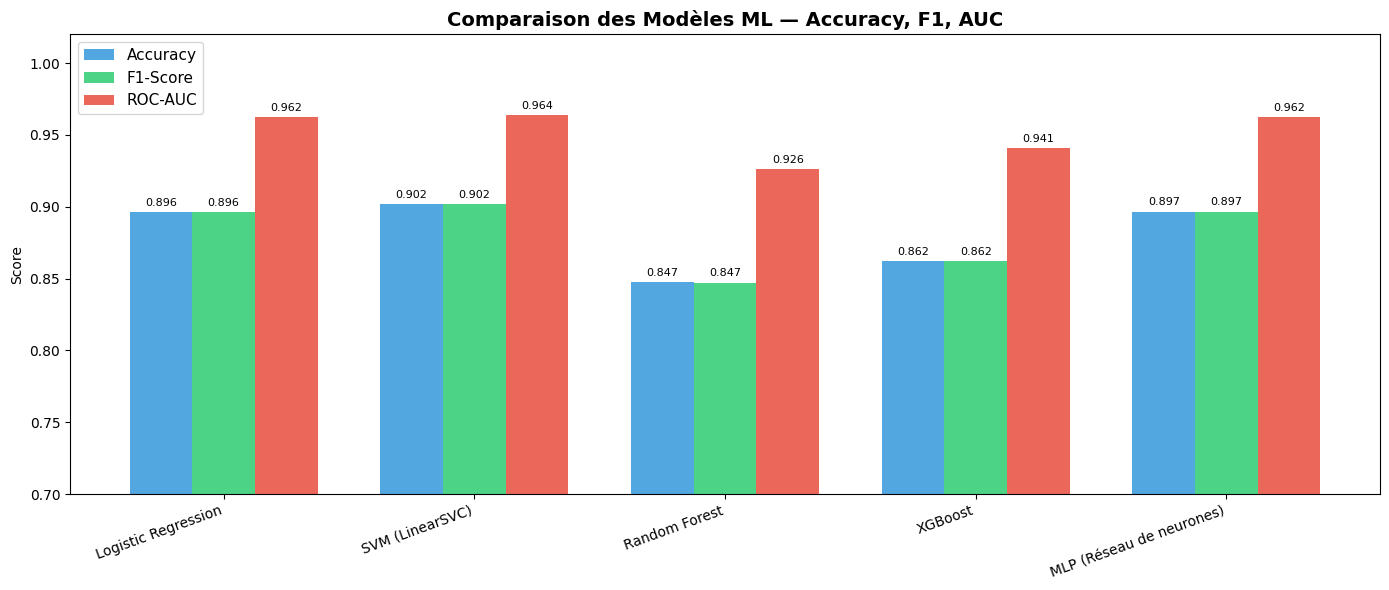

In [16]:
# ============================================================
# Graphique comparatif : Accuracy, F1, AUC
# ============================================================
noms    = list(resultats_ml.keys())
accus   = [resultats_ml[n]['accuracy'] for n in noms]
f1s     = [resultats_ml[n]['f1_score'] for n in noms]
aucs    = [resultats_ml[n]['auc']      for n in noms]

x = np.arange(len(noms))
w = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - w, accus, w, label='Accuracy',  color='#3498db', alpha=0.85)
bars2 = ax.bar(x,     f1s,   w, label='F1-Score',  color='#2ecc71', alpha=0.85)
bars3 = ax.bar(x + w, aucs,  w, label='ROC-AUC',   color='#e74c3c', alpha=0.85)

# Annotations
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)


ax.set_xticks(x)
ax.set_xticklabels(noms, rotation=20, ha='right', fontsize=10)
ax.set_ylim([0.7, 1.02])
ax.set_ylabel('Score')
ax.set_title('Comparaison des Modèles ML — Accuracy, F1, AUC', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

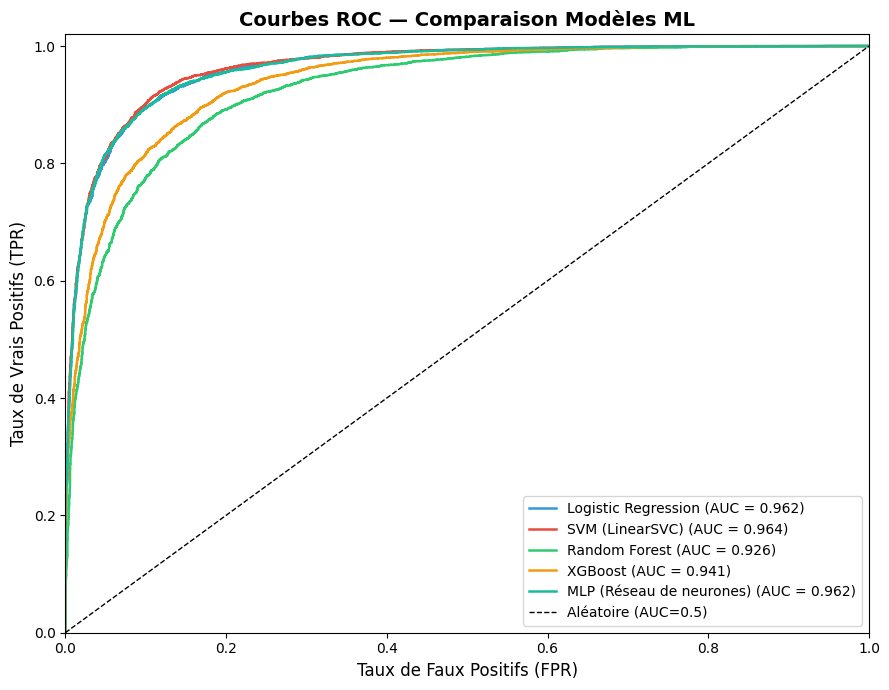

In [17]:
# ============================================================
# Courbes ROC superposées — Tous les modèles
# ============================================================
colors_roc = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#1abc9c', '#9b59b6']

fig, ax = plt.subplots(figsize=(9, 7))
for i, (nom, res) in enumerate(resultats_ml.items()):
    ax.plot(res['fpr'], res['tpr'], lw=1.8,
            color=colors_roc[i % len(colors_roc)],
            label=f"{nom} (AUC = {res['auc']:.3f})")

ax.plot([0,1],[0,1],'k--', lw=1, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison Modèles ML', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

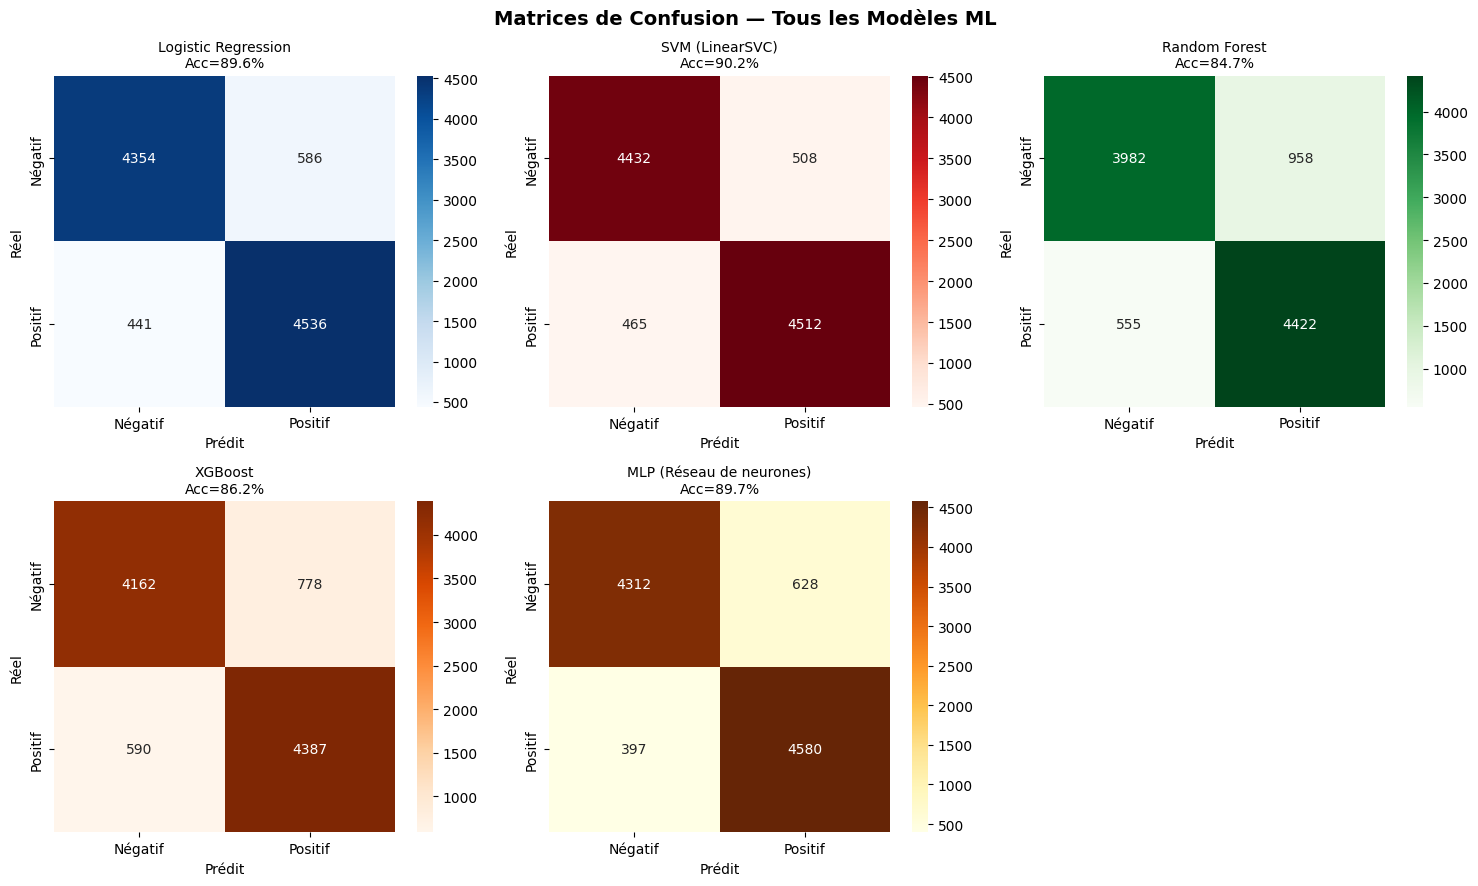

In [18]:
# ============================================================
# Matrices de confusion côte à côte — Tous les modèles
# ============================================================
n_models = len(resultats_ml)
fig, axes = plt.subplots(2, (n_models + 1) // 2, figsize=(15, 9))
axes = axes.flatten()

cmaps = ['Blues', 'Reds', 'Greens', 'Oranges', 'YlOrBr', 'Purples']

for i, (nom, res) in enumerate(resultats_ml.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i % len(cmaps)],
                xticklabels=['Négatif', 'Positif'],
                yticklabels=['Négatif', 'Positif'],
                ax=axes[i])
    axes[i].set_title(f"{nom}\nAcc={res['accuracy']*100:.1f}%", fontsize=10)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Matrices de Confusion — Tous les Modèles ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()